In [1]:
import torch
import sklearn
import torch.distributions as D
import numpy as np
from numpy.random import default_rng
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pymc3 as pm
import arviz as az

from insilico_stimuli.stimuli import GaborSet

seed = 42
rng = default_rng(seed=seed)
torch.manual_seed(seed=seed)
EPSILON = 1e-12
mpl.style.use("seaborn")
az.style.use("arviz-darkgrid")

# Defining the probabilistic model and posterior sampling


In [ ]:
def sample_posterior(stimulus, PFs):
    z_dim = 18
    Lambda = torch.ones(z_dim)
    sigma = torch.abs(torch.rand(1)) + EPSILON
    model = pm.Model()
    with model:
        z = pm.Exponential("neuron", lam=Lambda, shape=z_dim)
        x = pm.Normal(
            "stimulus", mu=(PFs.permute(1, 2, 0) @ z), sigma=sigma, observed=stimulus
        )
        trace = pm.sample(1_000, return_inferencedata=False)
    return trace

## Overlapping PFs

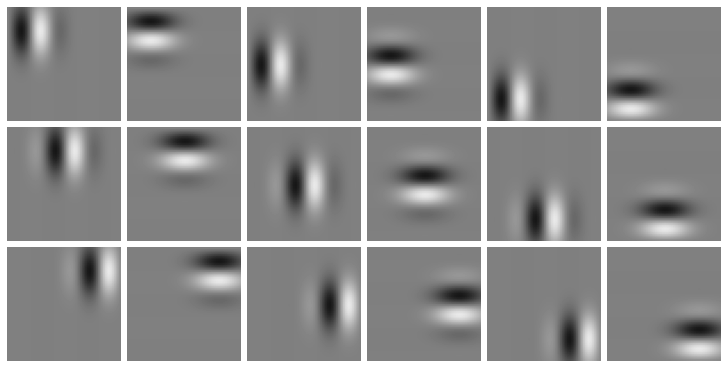

In [5]:
gabor_data_overlapping = torch.load("/src/project/computed/gabors_overlapping.pt")
gabors_overlapping = torch.tensor(gabor_data_overlapping["gabors"].images()).float()
plt.figure(figsize=(10, 5))
for i, img in enumerate(gabor_data_overlapping["gabors"].images()):
    plt.subplot(3, 6, i + 1)
    plt.imshow(img, cmap="gray", vmin=-1, vmax=1)
    plt.axis("off")